In [63]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [64]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
print(df)

       MedInc  HouseAge  AveRooms  ...  AveOccup  Latitude  Longitude
0      8.3252      41.0  6.984127  ...  2.555556     37.88    -122.23
1      8.3014      21.0  6.238137  ...  2.109842     37.86    -122.22
2      7.2574      52.0  8.288136  ...  2.802260     37.85    -122.24
3      5.6431      52.0  5.817352  ...  2.547945     37.85    -122.25
4      3.8462      52.0  6.281853  ...  2.181467     37.85    -122.25
...       ...       ...       ...  ...       ...       ...        ...
20635  1.5603      25.0  5.045455  ...  2.560606     39.48    -121.09
20636  2.5568      18.0  6.114035  ...  3.122807     39.49    -121.21
20637  1.7000      17.0  5.205543  ...  2.325635     39.43    -121.22
20638  1.8672      18.0  5.329513  ...  2.123209     39.43    -121.32
20639  2.3886      16.0  5.254717  ...  2.616981     39.37    -121.24

[20640 rows x 8 columns]


In [65]:
housing = fetch_california_housing()
print(housing)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8)), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset

In [66]:
column = 'AveRooms'

In [67]:
# step 1: Calculate Q1 and Q3
Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)

#Step2: Calculatae the Interquartile range
IQR = Q3 - Q1

# Step 3: Define the Lower and Upper bound
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


In [68]:
print(f"Column:{column}")
print(f"IQR:{IQR:.2f}")
print(f"Lower Bound:{lower_bound:.2f} | Upper Bound:{upper_bound:.2f}")

Column:AveRooms
IQR:1.61
Lower Bound:2.02 | Upper Bound:8.47


In [69]:
# filter the dataframe for outliers
outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
print(f"Total Rows:{len(df)}")
print(f"Outlier Rows:{len(outliers)}")


Total Rows:20640
Outlier Rows:511


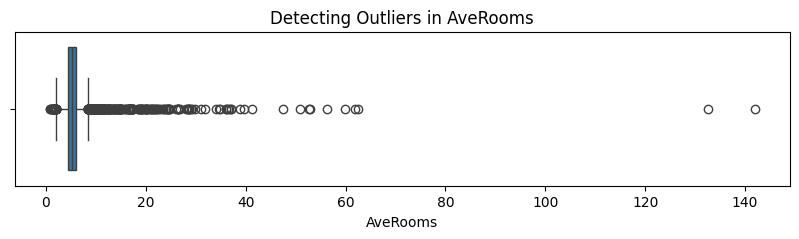

In [70]:
# Visualise with a boxplot
plt.figure(figsize=(10,2))
sns.boxplot(x=df[column])
plt.title(f"Detecting Outliers in {column}")
plt.show()

In [71]:
# Remve Outliers and keep only data within the bounds
df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
# Compare the size
print(f"Shape before:{df.shape}")
print(f"Shape after:{df_cleaned.shape}")





Shape before:(20640, 8)
Shape after:(20129, 8)


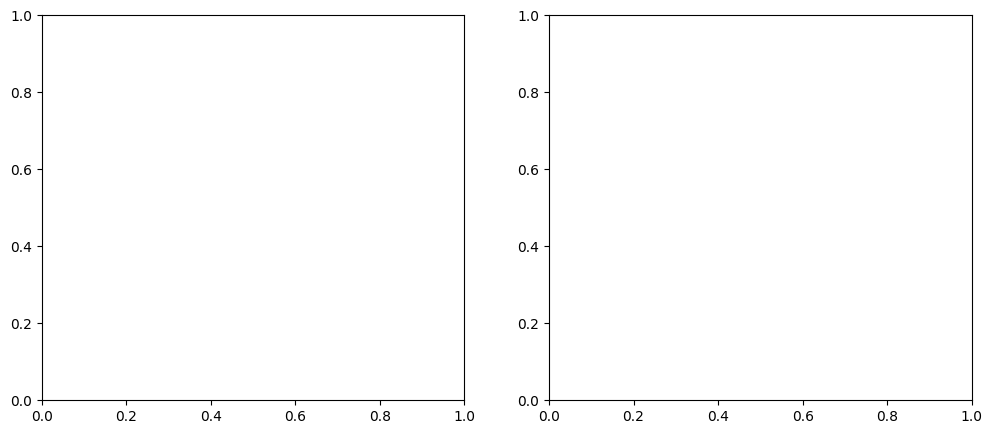

In [72]:
# Compare Distributions
fig,ax = plt.subplots(1,2,figsize=(12,5))
# subplot creates grid with 1 row and 2 col
#figsize=(12,5) makes the total visible area 12 inches wide by 5 inches tall
# fig is the entire canvas
# ax is the individual plot



In [73]:
sns.histplot(df[column], bins=50, ax=ax[0])
# bins=50 creates 50 bars in the histogram
# ax=ax[0] specifies that the histogram should be plotted on the first subplot

<Axes: xlabel='AveRooms', ylabel='Count'>

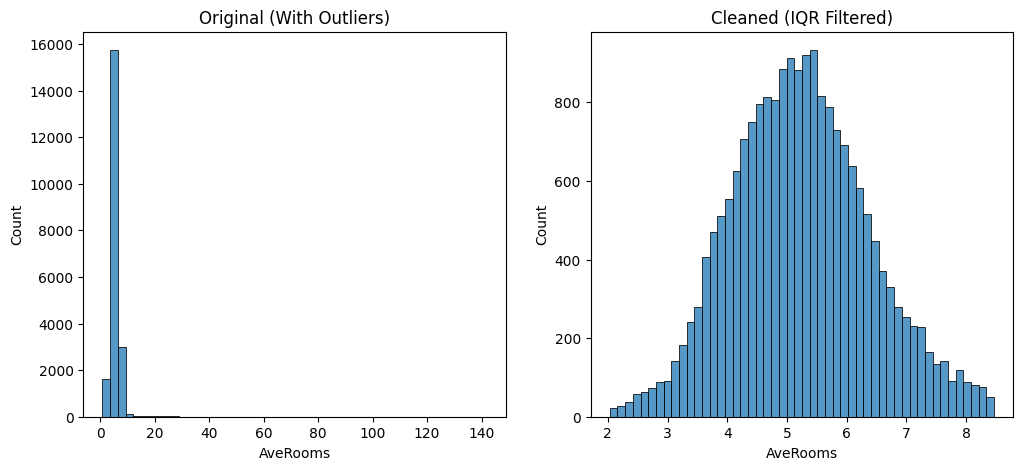

In [74]:
# Compare Distributions
fig,ax = plt.subplots(1,2,figsize=(12,5))
# subplot creates grid with 1 row and 2 col
#figsize=(12,5) makes the total visible area 12 inches wide by 5 inches tall
# fig is the entire canvas
# ax is the individual plot

sns.histplot(df[column], bins=50, ax=ax[0])
# bins=50 creates 50 bars in the histogram
# ax=ax[0] specifies that the histogram should be plotted on the first subplot

ax[0].set_title("Original (With Outliers)")
sns.histplot(df_cleaned[column],bins=50, ax=ax[1]).set_title("Cleaned (IQR Filtered)")
plt.show()

In [75]:
column2 = "AveBedrms"

In [76]:
# step 1: Calculate Q1 and Q3
Q1 = df[column2].quantile(0.25)
Q3 = df[column2].quantile(0.75)

#Step2: Calculatae the Interquartile range
IQR = Q3 - Q1

# Step 3: Define the Lower and Upper bound
lower_bound1 = Q1 - 1.5 * IQR
upper_bound1 = Q3 + 1.5 * IQR


In [77]:
print(f"Column:{column2}")
print(f"IQR:{IQR:.2f}")
print(f"Lower Bound:{lower_bound1:.2f} | Upper Bound:{upper_bound1:.2f}")

Column:AveBedrms
IQR:0.09
Lower Bound:0.87 | Upper Bound:1.24


In [83]:
# filter the dataframe for outliers
outliers1 = df[(df[column2] >= lower_bound1) | (df[column2] <= upper_bound1)]
print(f"Total Rows:{len(df)}")
print(f"Outlier Rows:{len(outliers1)}")


Total Rows:20640
Outlier Rows:20640


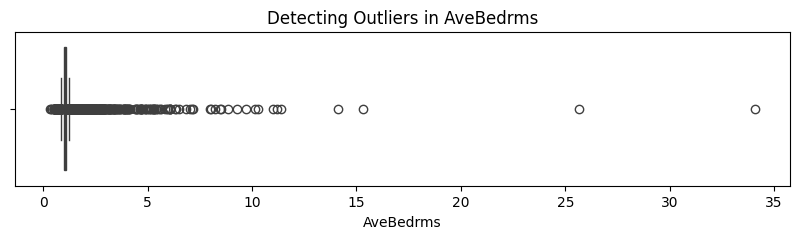

In [84]:
# Visualise with a boxplot
plt.figure(figsize=(10,2))
sns.boxplot(x=df[column2])
plt.title(f"Detecting Outliers in {column2}")
plt.show()

In [85]:
# Remve Outliers and keep only data within the bounds
df_cleaned1 = df[(df[column2] >= lower_bound1) & (df[column2] <= upper_bound1)]
# Compare the size
print(f"Shape before:{df.shape}")
print(f"Shape after:{df_cleaned1.shape}")





Shape before:(20640, 8)
Shape after:(19216, 8)


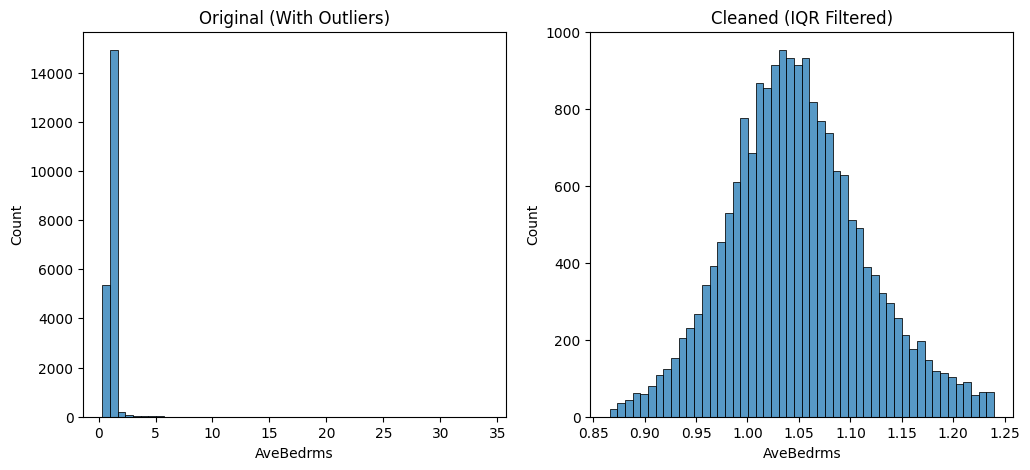

In [86]:
# Compare Distributions
fig,ax = plt.subplots(1,2,figsize=(12,5))
# subplot creates grid with 1 row and 2 col
#figsize=(12,5) makes the total visible area 12 inches wide by 5 inches tall
# fig is the entire canvas
# ax is the individual plot

sns.histplot(df[column2], bins=50, ax=ax[0])
# bins=50 creates 50 bars in the histogram
# ax=ax[0] specifies that the histogram should be plotted on the first subplot

ax[0].set_title("Original (With Outliers)")
sns.histplot(df_cleaned1[column2],bins=50, ax=ax[1]).set_title("Cleaned (IQR Filtered)")
plt.show()